In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import yaml
import pandas as pd

from IPython.display import Image, display

from data_models import Asset
from asset_news_graph import AssetNewsGraph, OverallAssetNewsState

In [3]:
from dotenv import load_dotenv

if load_dotenv():
    print("Environment variables loaded.")
else:
    print("No .env file found or failed to load.")

Environment variables loaded.


In [4]:
# Read assets from a YAML file

with open("../data/assets.yml", "r") as file:
    assets = yaml.safe_load(file)

print(assets)

{'asset_001': {'asset': '24K-999 Gold', 'description': 'Pure 24K gold bar for investment purposes', 'asset_class': 'Precious Metals', 'industry': 'Commodities', 'market': 'Global', 'quantity': 10, 'investment_unit': 'gram', 'buy_price_per_unit': 90, 'currency': 'SGD', 'date': '2024-01-15'}, 'asset_002': {'asset': 'Vanguard Information Technology Index Fund VGT ETF', 'description': 'ETF focusing on technology sector stocks', 'asset_class': 'Exchange Traded Funds', 'industry': 'Technology', 'market': 'US', 'quantity': 10, 'investment_unit': 'share', 'buy_price_per_unit': 550, 'currency': 'USD', 'date': '2024-07-15'}, 'asset_003': {'asset': 'CapitaLand Integrated Commercial Trust', 'description': 'REITs focused on commercial properties in Singapore', 'asset_class': 'REITs', 'industry': 'Real Estate', 'market': 'Singapore', 'quantity': 1000, 'investment_unit': 'share', 'buy_price_per_unit': 1.98, 'currency': 'SGD', 'date': '2022-12-15'}, 'asset_004': {'asset': '24K-999 Gold', 'description'

In [5]:
# Prepare a dataframe with input asset information

asset_df = (
    pd.DataFrame.from_dict(assets, orient="index")
    .reset_index()
    .rename(columns={"index": "asset_id"})
)

print(asset_df.shape)
asset_df.head()

(4, 11)


,asset_id,asset,description,asset_class,industry,market,quantity,investment_unit,buy_price_per_unit,currency,date
0,asset_001,24K-999 Gold,Pure 24K gold bar for investment purposes,Precious Metals,Commodities,Global,10,gram,90.00,SGD,2024-01-15
1,asset_002,Vanguard Information Technology Index Fund VGT...,ETF focusing on technology sector stocks,Exchange Traded Funds,Technology,US,10,share,550.00,USD,2024-07-15
2,asset_003,CapitaLand Integrated Commercial Trust,REITs focused on commercial properties in Sing...,REITs,Real Estate,Singapore,1000,share,1.98,SGD,2022-12-15
3,asset_004,24K-999 Gold,Pure 24K gold bar for investment purposes,Precious Metals,Commodities,Global,50,gram,180.00,SGD,2025-12-15


In [6]:
# Load unique assets to gather latest news

sel_cols = [
    "asset",
    "description",
    "asset_class",
    "industry",
    "market",
    "investment_unit",
    "currency",
]
unique_assets = asset_df.drop_duplicates(subset=sel_cols, keep="first").reset_index(
    drop=True
)
unique_assets = unique_assets[sel_cols]

print(unique_assets.shape)
unique_assets.head()

(3, 7)


,asset,description,asset_class,industry,market,investment_unit,currency
0,24K-999 Gold,Pure 24K gold bar for investment purposes,Precious Metals,Commodities,Global,gram,SGD
1,Vanguard Information Technology Index Fund VGT...,ETF focusing on technology sector stocks,Exchange Traded Funds,Technology,US,share,USD
2,CapitaLand Integrated Commercial Trust,REITs focused on commercial properties in Sing...,REITs,Real Estate,Singapore,share,SGD


In [7]:
# Load inputs for the agent

asset_list = []
for row in unique_assets.to_dict(orient="records"):
    try:
        asset_list.append(Asset(**row))
    except TypeError:
        asset_list.append(row)

print(f"Loaded {len(asset_list)} assets.")

Loaded 3 assets.


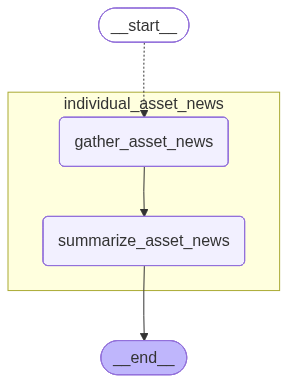

In [8]:
# Load the agent for collecting asset related news
asset_news_graph = AssetNewsGraph().contruct_graph().compile()

# Image(asset_news_graph.get_graph().draw_png())
display(Image(asset_news_graph.get_graph(xray=True).draw_mermaid_png()))

In [9]:
# Run the agent to get asset news information

state = OverallAssetNewsState(assets=asset_list)
result = None

thread = {"configurable": {"thread_id": "1"}}

for chunk in asset_news_graph.stream(state, thread=thread, stream_mode="values"):
    print("\n\nNew Chunk Received:\n")
    if "messages" in chunk:
        for m in chunk["messages"]:
            m.pretty_print()
    if "asset_news" in chunk:
        print("\n\nCompiled Asset News Information:")
        print(chunk["asset_news"])
        result = chunk["asset_news"]



New Chunk Received:



Compiled Asset News Information:
[]


New Chunk Received:



Compiled Asset News Information:
[AssetNewsInfo(asset='24K-999 Gold', description='Pure 24K gold bar for investment purposes', asset_class='Precious Metals', industry='Commodities', market='Global', investment_unit='gram', currency='SGD', news='As of mid-February 2026 (Feb 16–17), market reports show 24K (999) gold trading in the India/Delhi market around Rs 15,408–15,790 per gram (sources differ by time). Spot gold has been volatile: it fell to about $5,016.56/oz (reported) then recovered, with recent gains attributed to weaker US dollar and new US inflation data that increased expectations for a future Fed rate cut. Social and local market posts also show regional price updates (one post citing an approximate S$196.50/gram), but prices fluctuate daily and will vary by market and provider—check live financial feeds or local bullion dealers for the current SGD-denominated rate.', news_source=['https:/

In [10]:
# Parse the results and update the unique_assets dataframe

unique_assets["news"] = "NA"
unique_assets["news_sources"] = "NA"

for asset_news in result:
    unique_assets.loc[unique_assets["asset"] == asset_news.asset, "news"] = (
        asset_news.news
    )
    unique_assets.loc[unique_assets["asset"] == asset_news.asset, "news_sources"] = (
        ", ".join(asset_news.news_source)
    )

print(unique_assets.shape)
unique_assets.head()

(3, 9)


,asset,description,asset_class,industry,market,investment_unit,currency,news,news_sources
0,24K-999 Gold,Pure 24K gold bar for investment purposes,Precious Metals,Commodities,Global,gram,SGD,"As of mid-February 2026 (Feb 16–17), market re...",https://m.economictimes.com/wealth/invest/gold...
1,Vanguard Information Technology Index Fund VGT...,ETF focusing on technology sector stocks,Exchange Traded Funds,Technology,US,share,USD,As of mid-February 2026 (last trading day cite...,https://www.msn.com/en-us/money/etfdetails/vgt...
2,CapitaLand Integrated Commercial Trust,REITs focused on commercial properties in Sing...,REITs,Real Estate,Singapore,share,SGD,Recent updates: CICT reported H2 distribution ...,https://sginvestors.io/sgx/reit/c38u-capland-i...
